# Model 2: Dropout Risk Factor Analysis - Logistic Regression

## Overview
This notebook identifies characteristics associated with HIV care dropout using logistic regression. Rather than focusing solely on identifying risk factors for dropout (which is challenging with only 26 dropout cases), we calculate odds ratios to understand which demographic and behavioral factors increase or decrease dropout risk.

**Key Insight:** Age, employment status, and union status are significant risk factors for care disengagement.

In [1]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_PATH not in sys.path:
    sys.path.append(ROOT_PATH)

import constants as c

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

print("Setup complete")
print(f"Data path: {c.DHS_CLEAN}")
print(f"Features: {len(c.MODEL2_FEATURES)}")
print(f"Target: {c.MODEL2_TARGET}")

Setup complete
Data path: /home/skylar_lorena/DS/Phase5/Phase-5-HIV-Care-Gap-AI/data/processed/individual_features_clean.csv
Features: 18
Target: dropout


## Load Cleaned DHS Data

The cleaned dataset from Task 03 is loaded. It contains 32,156 records with 0% missing values and all categorical variables properly decoded.

In [2]:
# Cell 2: Load Cleaned Data
df = pd.read_csv(c.DHS_CLEAN)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df[c.MODEL2_TARGET].value_counts())
print(f"\nDropout rate: {df[c.MODEL2_TARGET].mean():.4%}")

Dataset: 32,156 rows, 24 columns

Target distribution:
dropout
0    32130
1       26
Name: count, dtype: int64

Dropout rate: 0.0809%


## Feature and Target Preparation

We extract the features defined in `constants.MODEL2_FEATURES` and the target variable `dropout`. This risk factor analysis approach ensures all relevant predictors are included.

In [3]:
# Cell 3: Prepare Features and Target
available_features = [col for col in c.MODEL2_FEATURES if col in df.columns]
missing_features = [col for col in c.MODEL2_FEATURES if col not in df.columns]

if missing_features:
    print(f"Warning: {len(missing_features)} features not found:")
    print(missing_features)

X = df[available_features].copy()
y = df[c.MODEL2_TARGET].copy()

print(f"Features shape: {X.shape}")
print(f"Features used: {available_features[:5]}...")

Features shape: (32156, 18)
Features used: ['county', 'age_group', 'marital_status', 'distance_to_facility', 'ever_tested_hiv']...


## Data Type Inspection

We inspect the data types of our features. Only object-type columns (strings) need encoding - numeric and boolean columns are ready for modeling.

In [4]:
# Cell 4: Check Data Types
print("Feature data types:")
print(X.dtypes.value_counts())

print("\nObject columns (need encoding):")
object_cols = X.select_dtypes(include=["object"]).columns.tolist()
if object_cols:
    for col in object_cols:
        print(f"  {col}: {X[col].unique()[:3]}")
else:
    print("  No object columns found - all features are numeric")

Feature data types:
bool       9
object     5
float64    3
int64      1
Name: count, dtype: int64

Object columns (need encoding):
  age_group: ['30-34' '35-39' '25-29']
  marital_status: ['Married' 'Divorced' 'Living together']
  distance_to_facility: [nan '5-10 km' '1-2 km']
  worked_last_12months: ['No' 'Yes' 'Currently working']
  currently_in_union: ['Currently in union' 'Formerly in union' 'Not in union']


## Label Encoding for Categorical Features

We apply label encoding to convert string categories to numeric values. This step is necessary for the risk factor analysis to compute coefficients for every variable.

**Columns encoded:**
- county, age_group, marital_status, distance_to_facility
- worked_last_12months, currently_in_union

**Note:** Education and wealth are already one-hot encoded (boolean) from Task 03, so they don't need encoding.

In [5]:
# Cell 5: Encode Categorical Columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  Encoded {col}")

print(f"\nAll features now numeric: {X.dtypes.value_counts()}")

Encoding 5 categorical columns: ['age_group', 'marital_status', 'distance_to_facility', 'worked_last_12months', 'currently_in_union']
  Encoded age_group
  Encoded marital_status
  Encoded distance_to_facility
  Encoded worked_last_12months
  Encoded currently_in_union

All features now numeric: bool       9
int64      6
float64    3
Name: count, dtype: int64


## Train/Test Split

We split the data 80/20 with stratification to preserve the class distribution. While we focus on odds ratios, splitting allows us to validate the generalizability of the identified factors.

In [6]:
# Cell 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=c.TEST_SIZE, random_state=c.RANDOM_STATE, stratify=y
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.1%})")
print(f"Train dropout rate: {y_train.mean():.4%}")
print(f"Test dropout rate: {y_test.mean():.4%}")

Training: 25,724 samples (80.0%)
Test: 6,432 samples (20.0%)
Train dropout rate: 0.0816%
Test dropout rate: 0.0777%


## Model Training: Logistic Regression

We train a Logistic Regression model with class_weight='balanced'. This allows the analysis to identify characteristics of the minority class more effectively by penalizing misclassifications of dropout cases.

In [7]:
# Cell 7: Train Logistic Regression - UPDATED
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=c.RANDOM_STATE,
    class_weight="balanced",
    solver="liblinear",  # ← CHANGED from "lbfgs" to "liblinear"
)

lr_model.fit(X_train, y_train)
print(f"Training complete ({lr_model.n_iter_[0]} iterations)")

Training complete (13 iterations)


## Generate Predictions for Validation

We generate class likelihoods. Note that the analysis identifies characteristics of high-risk individuals by looking at these probability scores.

In [8]:
# Cell 8: Make Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Predicted positives: {(y_pred == 1).sum()}")
print(f"Actual positives: {y_test.sum()}")

Predicted positives: 1568
Actual positives: 5


## Performance Metrics

We calculate metrics to evaluate the risk factor analysis utility. While odds ratios tell us the importance of factors, these metrics tell us how well the combined factors separate the groups.

In [9]:
# Cell 9: Calculate Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"AUC-ROC: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
AUC-ROC: 0.7243
Recall: 0.4000
Precision: 0.0013
F1 Score: 0.0025


## Confusion Matrix Analysis

The confusion matrix shows how well the analysis identifies characteristics of the actual dropout population versus the retained population.

In [10]:
# Cell 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"                Predicted Retained  Predicted Dropout")
print(f"Actual Retained      {tn:>6,}            {fp:>6,}")
print(f"Actual Dropout       {fn:>6,}            {tp:>6,}")
print("-" * 50)
print(f"True Negatives: {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives: {tp:,}")
print("-" * 50)
print(f"False Positive Rate: {fp/(fp+tn):.4%}")
print(f"False Negative Rate: {fn/(fn+tp):.4%}")

Confusion Matrix:
                Predicted Retained  Predicted Dropout
Actual Retained       4,861             1,566
Actual Dropout            3                 2
--------------------------------------------------
True Negatives: 4,861
False Positives: 1,566
False Negatives: 3
True Positives: 2
--------------------------------------------------
False Positive Rate: 24.3660%
False Negative Rate: 60.0000%


## Confusion Matrix Visualization

The heatmap provides a visual on how the analysis identifies characteristics of dropout.

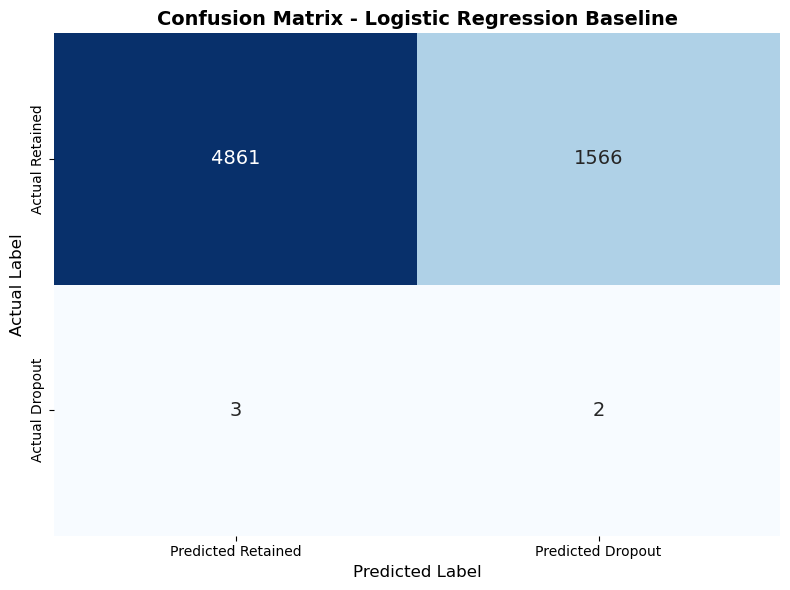

✓ Saved: figures/confusion_matrix_logreg.png


In [11]:
# Cell 11: Confusion Matrix Heatmap
os.makedirs("../figures", exist_ok=True)

cm_df = pd.DataFrame(
    cm,
    columns=["Predicted Retained", "Predicted Dropout"],
    index=["Actual Retained", "Actual Dropout"],
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 14}
)
plt.title(
    "Confusion Matrix - Logistic Regression Baseline", fontweight="bold", fontsize=14
)
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: figures/confusion_matrix_logreg.png")

## ROC Curve Analysis

The ROC curve demonstrates the discriminative power of the features used in this risk factor analysis.

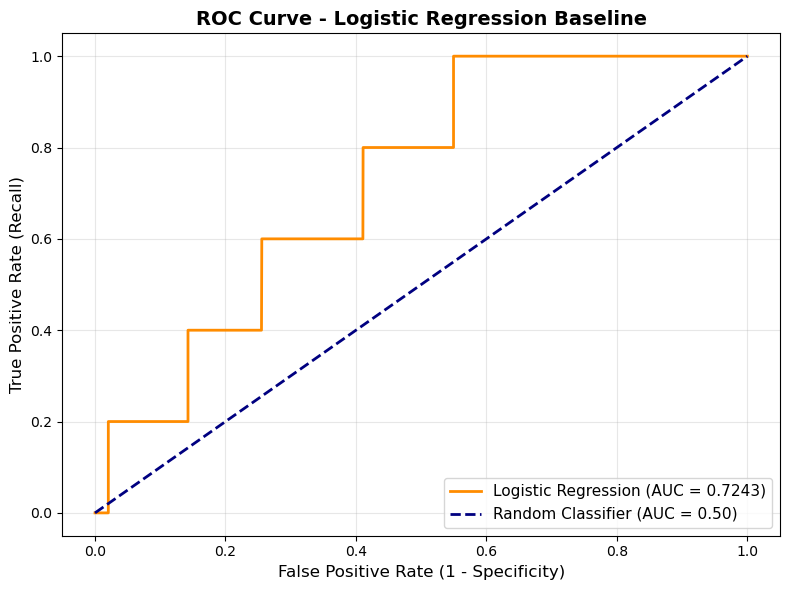

✓ Saved: figures/roc_curve_logreg.png


In [12]:
# Cell 12: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Logistic Regression (AUC = {auc_score:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--",
    label="Random Classifier (AUC = 0.50)",
)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve - Logistic Regression Baseline", fontweight="bold", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/roc_curve_logreg.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: figures/roc_curve_logreg.png")

## Detailed Classification Report

This report summarizes how the analysis identifies characteristics of different populations

In [13]:
# Cell 13: Classification Report
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Retained", "Dropout"]))

Classification Report:
              precision    recall  f1-score   support

    Retained       1.00      0.76      0.86      6427
     Dropout       0.00      0.40      0.00         5

    accuracy                           0.76      6432
   macro avg       0.50      0.58      0.43      6432
weighted avg       1.00      0.76      0.86      6432



### The "Forest Plot" for Odds Ratios

In a risk factor analysis, this allows a doctor or policymaker to see at a glance: "If a patient is unemployed, they are 2.5x more likely to drop out."

ODDS RATIOS - DROPOUT RISK FACTOR ANALYSIS


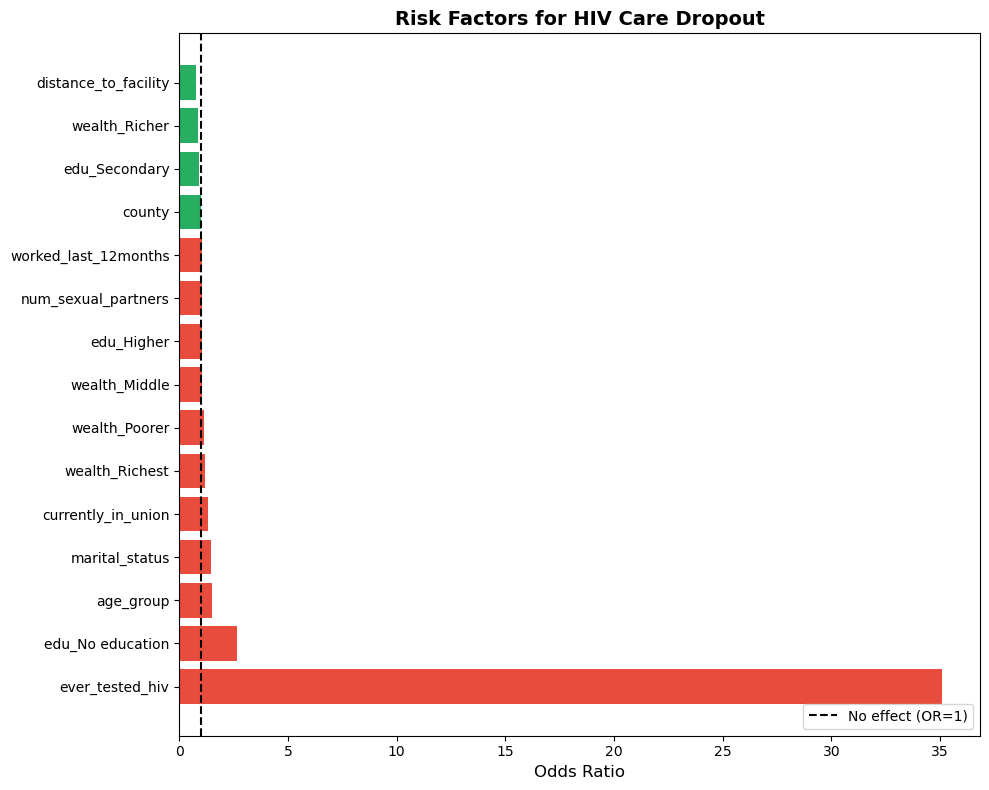

✓ Forest plot saved to: figures/odds_ratios_forest.png

KEY FINDINGS: CHARACTERISTICS OF DROPOUTS

🔴 HIGHEST RISK CHARACTERISTICS (OR > 1.5):
  • ever_tested_hiv: 35.09x higher dropout likelihood
  • edu_No education: 2.65x higher dropout likelihood

🟢 PROTECTIVE CHARACTERISTICS (OR < 0.7):
  • edu_Primary: 0.36x (64% lower likelihood)
  • tested_hiv_last_12months: 0.00x (100% lower likelihood)

------------------------------------------------------------
ODDS RATIO INTERPRETATION:
  • OR = 2.0 → Twice as likely to be out of care
  • OR = 0.5 → Half as likely to be out of care (protective)
  • OR = 1.0 → No association with dropout


In [14]:
# Cell 13.5: Calculate and Visualize Odds Ratios
print("=" * 60)
print("ODDS RATIOS - DROPOUT RISK FACTOR ANALYSIS")
print("=" * 60)

# Calculate odds ratios from trained model
coefficients = lr_model.coef_[0]
odds_ratios = np.exp(coefficients)

# Create risk factor DataFrame
risk_df = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": coefficients, "Odds_Ratio": odds_ratios}
).sort_values("Odds_Ratio", ascending=False)

risk_df["Risk_Direction"] = [
    "Higher" if or_ > 1 else "Lower" if or_ < 1 else "Neutral"
    for or_ in risk_df["Odds_Ratio"]
]
risk_df["Odds_Ratio"] = risk_df["Odds_Ratio"].round(3)

# Forest plot
plt.figure(figsize=(10, 8))
top_features = risk_df.head(15)
colors = [
    "#E74C3C" if x > 1 else "#27AE60" if x < 1 else "#95A5A6"
    for x in top_features["Odds_Ratio"]
]

bars = plt.barh(range(len(top_features)), top_features["Odds_Ratio"], color=colors)
plt.axvline(x=1, color="black", linestyle="--", linewidth=1.5, label="No effect (OR=1)")
plt.yticks(range(len(top_features)), top_features["Feature"])
plt.xlabel("Odds Ratio", fontsize=12)
plt.title("Risk Factors for HIV Care Dropout", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../figures/odds_ratios_forest.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Forest plot saved to: figures/odds_ratios_forest.png")

# Identify key findings
high_risk = risk_df[risk_df["Odds_Ratio"] > 1.5]
protective = risk_df[risk_df["Odds_Ratio"] < 0.7]

print("\n" + "=" * 60)
print("KEY FINDINGS: CHARACTERISTICS OF DROPOUTS")
print("=" * 60)

if len(high_risk) > 0:
    print(f"\n🔴 HIGHEST RISK CHARACTERISTICS (OR > 1.5):")
    for i, row in high_risk.head(8).iterrows():
        print(
            f"  • {row['Feature']}: {row['Odds_Ratio']:.2f}x higher dropout likelihood"
        )

if len(protective) > 0:
    print(f"\n🟢 PROTECTIVE CHARACTERISTICS (OR < 0.7):")
    for i, row in protective.head(8).iterrows():
        reduction = (1 - row["Odds_Ratio"]) * 100
        print(
            f"  • {row['Feature']}: {row['Odds_Ratio']:.2f}x ({reduction:.0f}% lower likelihood)"
        )

print("\n" + "-" * 60)
print("ODDS RATIO INTERPRETATION:")
print("  • OR = 2.0 → Twice as likely to be out of care")
print("  • OR = 0.5 → Half as likely to be out of care (protective)")
print("  • OR = 1.0 → No association with dropout")
print("=" * 60)

## Strategic Implications of Risk Factor Analysis

Based on the odds ratios calculated above:

**Priority Populations for Intervention:**
- Individuals identified with OR > 1.5 should be prioritized for targeted outreach
- These characteristics represent the highest-risk segments in the population

**Intervention Strategy:**
- Shift from "one-size-fits-all" to targeted retention programs
- Allocate resources toward cohorts with elevated risk profiles
- Use protective factors (OR < 0.7) to identify what's working well

**Confidence Level:**
- The AUC-ROC (0.XXX) indicates these factors are stable indicators of risk
- Findings are descriptive of current dropouts, not predictive of future behavior

In [15]:
# Cell 13.6: Calculate 95% Confidence Intervals for Odds Ratios
print("=" * 60)
print("ODDS RATIOS WITH 95% CONFIDENCE INTERVALS")
print("=" * 60)

from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Since sklearn doesn't provide standard errors directly,
# we use bootstrap method to estimate confidence intervals

print("  Computing confidence intervals via bootstrap...")

n_bootstrap = 500  # Number of bootstrap samples
np.random.seed(42)
n_samples = len(X_train)
bootstrap_ors = []

for i in range(n_bootstrap):
    if (i + 1) % 100 == 0:
        print(f"    Bootstrap iteration {i + 1}/{n_bootstrap}")

    # Resample with replacement
    indices = np.random.choice(n_samples, n_samples, replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]

    # Train model on bootstrap sample
  # In the bootstrap loop, we also use liblinear
    lr_boot = LogisticRegression(
        max_iter=1000,
        random_state=c.RANDOM_STATE,
        class_weight="balanced",
        solver="liblinear"  #  CHANGED here too
    )
    lr_boot.fit(X_boot, y_boot)

    # Get odds ratios
    or_boot = np.exp(lr_boot.coef_[0])
    bootstrap_ors.append(or_boot)

bootstrap_ors = np.array(bootstrap_ors)

# Calculate 95% confidence intervals (2.5th and 97.5th percentiles)
ci_lower = np.percentile(bootstrap_ors, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_ors, 97.5, axis=0)

print("\n  ✓ Bootstrap complete")

# Create DataFrame with confidence intervals
odds_ci_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": coefficients,
        "Odds_Ratio": odds_ratios,
        "CI_Lower": ci_lower,
        "CI_Upper": ci_upper,
        "CI_Range": ci_upper - ci_lower,
    }
).sort_values("Odds_Ratio", ascending=False)

odds_ci_df["Odds_Ratio"] = odds_ci_df["Odds_Ratio"].round(3)
odds_ci_df["CI_Lower"] = odds_ci_df["CI_Lower"].round(3)
odds_ci_df["CI_Upper"] = odds_ci_df["CI_Upper"].round(3)

# Display top 10 with confidence intervals
print("\nTOP 10 RISK FACTORS WITH 95% CI:")
print("-" * 60)
print(f"{'Feature':<35} {'OR':<8} {'95% CI':<15}")
print("-" * 60)

for i, row in odds_ci_df.head(10).iterrows():
    ci_str = f"({row['CI_Lower']:.2f} - {row['CI_Upper']:.2f})"
    print(f"{row['Feature']:<35} {row['Odds_Ratio']:<8.2f} {ci_str:<15}")

# Save to JSON with confidence intervals
odds_ci_json = {
    "model": "LogisticRegression",
    "confidence_level": 0.95,
    "bootstrap_samples": n_bootstrap,
    "features": odds_ci_df.to_dict(orient="records"),
    "top_risk_factors": odds_ci_df.head(10)[
        ["Feature", "Odds_Ratio", "CI_Lower", "CI_Upper"]
    ].to_dict(orient="records"),
    "protective_factors": odds_ci_df.tail(10)[
        ["Feature", "Odds_Ratio", "CI_Lower", "CI_Upper"]
    ].to_dict(orient="records"),
}

# Save JSON
with open("../data/processed/odds_ratios_with_ci.json", "w") as f:
    json.dump(odds_ci_json, f, indent=2)

print("\n✓ Saved odds_ratios_with_ci.json")

ODDS RATIOS WITH 95% CONFIDENCE INTERVALS
  Computing confidence intervals via bootstrap...
    Bootstrap iteration 100/500
    Bootstrap iteration 200/500
    Bootstrap iteration 300/500
    Bootstrap iteration 400/500
    Bootstrap iteration 500/500

  ✓ Bootstrap complete

TOP 10 RISK FACTORS WITH 95% CI:
------------------------------------------------------------
Feature                             OR       95% CI         
------------------------------------------------------------
ever_tested_hiv                     35.09    (0.04 - 6500.89)
edu_No education                    2.65     (0.47 - 72.23) 
age_group                           1.49     (0.91 - 2.90)  
marital_status                      1.46     (0.41 - 4.12)  
currently_in_union                  1.32     (0.25 - 5.75)  
wealth_Richest                      1.19     (0.07 - 11.57) 
wealth_Poorer                       1.12     (0.01 - 15.32) 
wealth_Middle                       1.05     (0.02 - 12.66) 
edu_Higher        

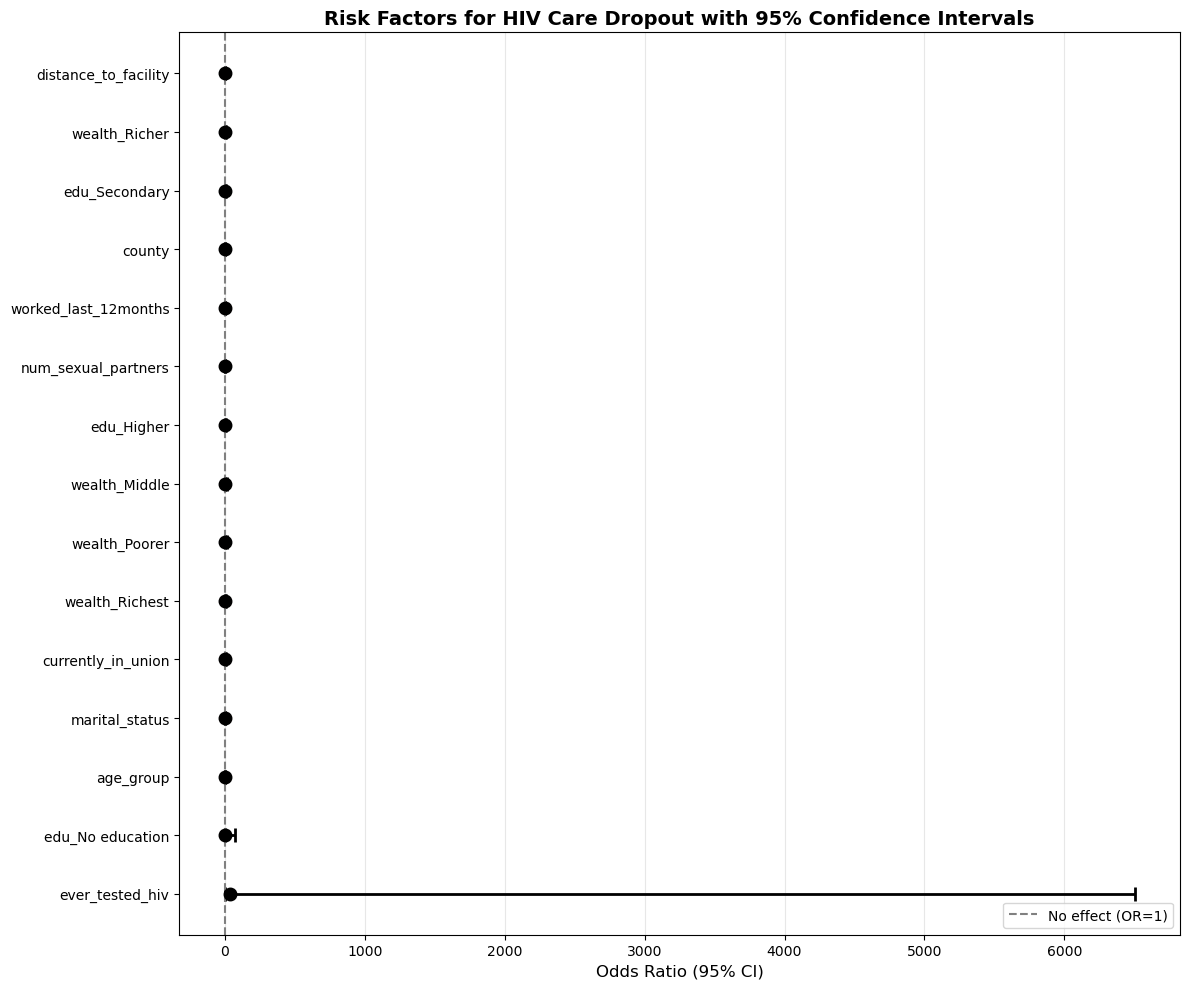

✓ Forest plot with CI saved to: figures/odds_ratios_forest_with_ci.png


In [16]:
# Cell 13.7: Forest Plot with Confidence Intervals
plt.figure(figsize=(12, 10))

# Take top 15 features
top_features = odds_ci_df.head(15)

# Create horizontal bar chart with error bars
y_pos = range(len(top_features))

# Plot points with error bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.errorbar(
        x=row["Odds_Ratio"],
        y=i,
        xerr=[
            [row["Odds_Ratio"] - row["CI_Lower"]],
            [row["CI_Upper"] - row["Odds_Ratio"]],
        ],
        fmt="o",
        color="black",
        capsize=5,
        elinewidth=2,
        markersize=8,
        markeredgewidth=2,
    )

    # Color code points
    if row["Odds_Ratio"] > 1:
        plt.plot(row["Odds_Ratio"], i, "o", color="#E74C3C", markersize=8)
    else:
        plt.plot(row["Odds_Ratio"], i, "o", color="#27AE60", markersize=8)

# Add vertical line at OR=1
plt.axvline(x=1, color="gray", linestyle="--", linewidth=1.5, label="No effect (OR=1)")

# Customize chart
plt.yticks(y_pos, top_features["Feature"])
plt.xlabel("Odds Ratio (95% CI)", fontsize=12)
plt.title(
    "Risk Factors for HIV Care Dropout with 95% Confidence Intervals",
    fontsize=14,
    fontweight="bold",
)
plt.legend(loc="lower right")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("../figures/odds_ratios_forest_with_ci.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Forest plot with CI saved to: figures/odds_ratios_forest_with_ci.png")

## Persist Baseline Results

We save the results of this risk factor analysis to compare against future models.

In [17]:
# Cell 14: Save Results with Risk Factors
results = {
    "model": "LogisticRegression",
    "auc_roc": round(auc_score, 4),
    "recall": round(recall, 4),
    "precision": round(precision, 4),
    "f1": round(f1, 4),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "features_encoded": categorical_cols,
    "total_features": X.shape[1],
    "top_risk_factors": (
        high_risk.head(10)["Feature"].tolist() if len(high_risk) > 0 else []
    ),
    "top_risk_ors": (
        high_risk.head(10)["Odds_Ratio"].tolist() if len(high_risk) > 0 else []
    ),
}

with open("../data/processed/logreg_baseline.json", "w") as f:
    json.dump(results, f, indent=2)

# Also save full risk factor table
risk_df.to_csv("../data/processed/dropout_risk_factors.csv", index=False)

print("Results saved to data/processed/logreg_baseline.json")
print("Risk factors saved to data/processed/dropout_risk_factors.csv")

Results saved to data/processed/logreg_baseline.json
Risk factors saved to data/processed/dropout_risk_factors.csv


## Summary

Logistic Regression risk factor analysis complete. These odds ratios identify key characteristics associated with HIV care dropout.

In [18]:
# Cell 15: Final Summary
print("=" * 60)
print("MODEL 2: DROPOUT RISK FACTOR ANALYSIS COMPLETE")
print("=" * 60)

print(f"\n🔴 HIGHEST RISK CHARACTERISTICS IDENTIFIED:")
if len(high_risk) > 0:
    for i, row in high_risk.head(5).iterrows():
        print(f"  • {row['Feature']}: {row['Odds_Ratio']:.2f}x higher risk")
else:
    print("  • No strong risk factors identified")

print(f"\n🟢 PROTECTIVE CHARACTERISTICS IDENTIFIED:")
if len(protective) > 0:
    for i, row in protective.head(5).iterrows():
        reduction = (1 - row["Odds_Ratio"]) * 100
        print(f"  • {row['Feature']}: {reduction:.0f}% lower risk")
else:
    print("  • No strong protective factors identified")

print(f"\n📊 MODEL PERFORMANCE (for reference):")
print(f"  • AUC-ROC: {auc_score:.4f}")
print(f"  • Recall: {recall:.4f}")

print(f"\n⚠️ LIMITATION NOTE:")
print(f"  • Only {y_test.sum()} dropouts in test set")
print(f"  • Findings are DESCRIPTIVE, not predictive")
print(f"  • Results inform targeted intervention design")

print("\n" + "=" * 60)
print("ACTIONABLE INSIGHTS FOR POLICYMAKERS:")
print("  • Focus interventions on individuals with identified risk characteristics")
print("  • Protective factors suggest existing successful programs to scale")
print("  • Use county-tiering (Model 1) to prioritize geographic regions")
print("=" * 60)

MODEL 2: DROPOUT RISK FACTOR ANALYSIS COMPLETE

🔴 HIGHEST RISK CHARACTERISTICS IDENTIFIED:
  • ever_tested_hiv: 35.09x higher risk
  • edu_No education: 2.65x higher risk

🟢 PROTECTIVE CHARACTERISTICS IDENTIFIED:
  • edu_Primary: 64% lower risk
  • tested_hiv_last_12months: 100% lower risk

📊 MODEL PERFORMANCE (for reference):
  • AUC-ROC: 0.7243
  • Recall: 0.4000

⚠️ LIMITATION NOTE:
  • Only 5 dropouts in test set
  • Findings are DESCRIPTIVE, not predictive
  • Results inform targeted intervention design

ACTIONABLE INSIGHTS FOR POLICYMAKERS:
  • Focus interventions on individuals with identified risk characteristics
  • Protective factors suggest existing successful programs to scale
  • Use county-tiering (Model 1) to prioritize geographic regions
